# 1. Cài đặt các thư viện cần thiết

In [1]:
pip install --upgrade pip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 22.0.4
    Uninstalling pip-22.0.4:
      Successfully uninstalled pip-22.0.4
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install wheel

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/kaggle/input/student-feedback-dataset/Dataset3.csv")
df = df.drop(df[df['Sentiments'] == 1].index)
df.loc[df['Sentiments'] == 2, 'Sentiments'] = 1


In [4]:
df_pos = df[df['Sentiments']==1]
df_neg = df[df['Sentiments']==0]
df_pos_downsampled = df_pos.sample(df_neg.shape[0])
df_balanced = pd.concat([df_pos_downsampled, df_neg])

In [5]:
import numpy as np

In [6]:
labels = np.array(df_balanced['Sentiments'])
comments = df_balanced['Comments'].tolist()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_remain, y_train, y_remain = train_test_split(comments, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_remain, y_remain, test_size=0.5, random_state=42)

In [8]:
max_length_train = 0
for sentence in X_train:
    words = sentence.split()
    if len(words) > max_length_train:
        max_length_train = len(words)
max_length_test = 0
for sentence in X_test:
    words = sentence.split()
    if len(words) > max_length_test:
        max_length_test = len(words)
max_length_val = 0
for sentence in X_val:
    words = sentence.split()
    if len(words) > max_length_val:
        max_length_val = len(words)
MAX_LEN = max_length_train
if max_length_test > MAX_LEN:
    MAX_LEN = max_length_test
if max_length_val > MAX_LEN:
    MAX_LEN = max_length_val

In [5]:
# load pre-trained BERT và tune
!pip install transformers
!pip install fastBPE
!pip install fairseq

  Preparing metadata (setup.py) ... done
  Created wheel for fastBPE: filename=fastBPE-0.1.0-cp37-cp37m-linux_x86_64.whl size=746870 sha256=a206ae64a0c7be85ee8eb524ccba18865d33a60ce4014dbe3273ae1e3c1e98f2
  Stored in directory: /root/.cache/pip/wheels/bd/d4/0e/0d317a65f77d3f8049fedd8a2ee0519164cf3e6bd77ef886f1
Successfully built fastBPE
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 47.6 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 KB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.0/265.0 KB 25.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 KB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 KB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.8-py3-none-any.whl size=141230 sha256=add0b08d9fde0912399d4976019bbb1ac2bfe9ea3fac8d0bd2332b16a5a83a05
  Stored in directory: /r

In [6]:
# Thư viện vncorenlp và wordsegmenter dùng để Word Segmentation cho tiếng Việt

# Install the vncorenlp python wrapper
!pip install vncorenlp

# Download VnCoreNLP-1.1.1.jar & its word segmentation component (i.e. RDRSegmenter) 
!mkdir -p vncorenlp/models/wordsegmenter
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr
!mv VnCoreNLP-1.1.1.jar vncorenlp/ 
!mv vi-vocab vncorenlp/models/wordsegmenter/
!mv wordsegmenter.rdr vncorenlp/models/wordsegmenter/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645951 sha256=63271907b62e81595c5dc6d3bbce2399a6cc2605946037a6981206f8197b78e8
  Stored in directory: /root/.cache/pip/wheels/0c/d8/f2/d28d97379b4f6479bf51247c8dfd57fa00932fa7a74b6aab29
Successfully built vncorenlp
--2023-06-24 13:43:59--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412575 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.1.1.jar’

VnCoreNLP-1.1.1.jar 100%[===================>]  26.14M  --.-KB/s    in 0.1s    

2023-06-24 13:44:01 (236 MB/s) - ‘

In [7]:
# Tải về bộ dữ liệu huấn luyện từ trang chủ cuộc thi của AIVIVN và 
# pre-trained của PhoBERT xong tiến hành giải nén

!wget https://public.vinai.io/PhoBERT_base_transformers.tar.gz
!tar -xzvf PhoBERT_base_transformers.tar.gz

--2023-06-24 13:44:13--  https://public.vinai.io/PhoBERT_base_transformers.tar.gz
Resolving public.vinai.io (public.vinai.io)... 13.227.219.12, 13.227.219.120, 13.227.219.93, ...
Connecting to public.vinai.io (public.vinai.io)|13.227.219.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 322405979 (307M) [application/x-tar]
Saving to: ‘PhoBERT_base_transformers.tar.gz’

PhoBERT_base_transf 100%[===================>] 307.47M  19.7MB/s    in 15s     

2023-06-24 13:44:29 (20.4 MB/s) - ‘PhoBERT_base_transformers.tar.gz’ saved [322405979/322405979]

PhoBERT_base_transformers/
PhoBERT_base_transformers/config.json
PhoBERT_base_transformers/bpe.codes
PhoBERT_base_transformers/model.bin
PhoBERT_base_transformers/dict.txt


In [8]:
import os
import torch
import pickle
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from vncorenlp import VnCoreNLP

import argparse
from fairseq.data import Dictionary
from fairseq.data.encoders.fastbpe import fastBPE

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score

from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import RobertaForSequenceClassification, RobertaConfig, AdamW
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

import warnings
warnings.filterwarnings("ignore")

In [9]:
# tạo bộ word segmentation cho tiếng Việt
rdrsegmenter = VnCoreNLP("./vncorenlp/VnCoreNLP-1.1.1.jar", annotators="wseg", max_heap_size='-Xmx500m')

In [10]:
# load model và bpe lên theo hướng dẫn của PhoBERT
parser = argparse.ArgumentParser()
parser.add_argument('--bpe-codes', 
    default="./PhoBERT_base_transformers/bpe.codes",
    required=False,
    type=str,
    help='path to fastBPE BPE'
)
args, unknown = parser.parse_known_args()
bpe = fastBPE(args)

# Load the dictionary
vocab = Dictionary()
vocab.add_from_file("./PhoBERT_base_transformers/dict.txt")

Loading codes from ./PhoBERT_base_transformers/bpe.codes ...
Read 64000 codes from the codes file.


In [11]:
def convert_sents_ids(sents):
    ids = []
    for sent in sents:
        subwords = '<s> ' + bpe.encode(sent) + ' </s>'
        encoded_sent = vocab.encode_line(subwords, append_eos=True, add_if_not_exist=False).long().tolist()
        ids.append(encoded_sent)
    ids = pad_sequences(ids, maxlen=161, dtype="long", value=0, truncating="post", padding="post")
    return torch.tensor(ids)

In [ ]:
train_ids = convert_sents_ids(X_train)
val_ids = convert_sents_ids(X_val)
test_ids = convert_sents_ids(X_test)

In [12]:
def make_mask(batch_ids):
    batch_mask = []
    for ids in batch_ids:
        mask = [int(token_id > 0) for token_id in ids]
        batch_mask.append(mask)
    return torch.tensor(batch_mask)

In [ ]:
train_masks = make_mask(train_ids)
val_masks = make_mask(val_ids)
test_masks = make_mask(test_ids)

In [13]:
def make_data_loader(ids, masks, labels, BATCH_SIZE=4): 
    data = TensorDataset(ids, masks, labels)
    sampler = SequentialSampler(data)
    dataloader = DataLoader(data, sampler=sampler, batch_size=BATCH_SIZE) #32
    return dataloader

In [ ]:
train_labels = torch.tensor(y_train)
val_labels = torch.tensor(y_val)
test_labels = torch.tensor(y_test)

train_dataloader = make_data_loader(train_ids, train_masks, train_labels)
val_dataloader = make_data_loader(val_ids, val_masks, val_labels)
test_dataloader = make_data_loader(test_ids, test_masks, test_labels)

In [14]:
NUM_LABELS = 2
config = RobertaConfig.from_pretrained(
    "./PhoBERT_base_transformers/config.json", from_tf=False, num_labels = NUM_LABELS, output_hidden_states=False,
)
PHO_BERT = RobertaForSequenceClassification.from_pretrained(
    "./PhoBERT_base_transformers/model.bin",
    config=config
)

PHO_BERT.cuda()
print('Done')


You are using a model of type bert to instantiate a model of type roberta. This is not supported for all configurations of models and can yield errors.
Some weights of the model checkpoint at ./PhoBERT_base_transformers/model.bin were not used when initializing RobertaForSequenceClassification: ['lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.decoder.bias', 'lm_head.bias', 'lm_head.decoder.weight', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenc

Done


In [15]:
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    
    F1_score = f1_score(pred_flat, labels_flat, average='macro')
    
    return accuracy_score(pred_flat, labels_flat), F1_score


In [19]:
device = 'cuda'
EPOCHS = 5

param_optimizer = list(PHO_BERT.named_parameters())
no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]

optimizer = AdamW(optimizer_grouped_parameters, lr=1e-5, correct_bias=False)

TRAIN_ACCURACY, TRAIN_F1, TRAIN_LOSS, VAL_ACCURACY , VAL_F1 = [], [], [], [], []

for epoch_i in range(0, EPOCHS):
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, EPOCHS))
    print('Training...')

    total_loss = 0
    PHO_BERT.train()
    train_accuracy = 0
    nb_train_steps = 0
    train_f1 = 0
    
    for step, batch in tqdm(enumerate(train_dataloader)):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch
        
        PHO_BERT.zero_grad()
        outputs = PHO_BERT(b_input_ids, 
            token_type_ids=None, 
            attention_mask=b_input_mask, 
            labels=b_labels)
        loss = outputs[0]
        total_loss += loss.item()
        
        logits = outputs[1].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        tmp_train_accuracy, tmp_train_f1 = flat_accuracy(logits, label_ids)
        train_accuracy += tmp_train_accuracy
        train_f1 += tmp_train_f1
        nb_train_steps += 1
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(PHO_BERT.parameters(), 1.0)
        optimizer.step()
        
    avg_train_loss = total_loss / len(train_dataloader)
    TRAIN_LOSS.append(avg_train_loss)
    TRAIN_ACCURACY.append(train_accuracy/nb_train_steps)
    TRAIN_F1.append(train_f1/nb_train_steps)
    print(" Accuracy: {0:.4f}".format(train_accuracy/nb_train_steps))
    print(" F1 score: {0:.4f}".format(train_f1/nb_train_steps))
    print(" Average training loss: {0:.4f}".format(avg_train_loss))
    PHO_BERT.save_pretrained('/kaggle/working/{}'.format(epoch_i+1))
    print("Running Validation...")
    PHO_BERT.eval()
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0
    eval_f1 = 0
    for batch in tqdm(val_dataloader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = PHO_BERT(b_input_ids, 
                              token_type_ids=None, 
                              attention_mask=b_input_mask)
            logits = outputs[0]
            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()

            tmp_eval_accuracy, tmp_eval_f1 = flat_accuracy(logits, label_ids)

            eval_accuracy += tmp_eval_accuracy
            eval_f1 += tmp_eval_f1
            nb_eval_steps += 1
    VAL_ACCURACY.append(eval_accuracy/nb_eval_steps)
    VAL_F1.append(eval_f1/nb_eval_steps)
    print(" Accuracy: {0:.4f}".format(eval_accuracy/nb_eval_steps))
    print(" F1 score: {0:.4f}".format(eval_f1/nb_eval_steps))
print("Training complete!")


======== Epoch 1 / 5 ========
Training...


0it [00:00, ?it/s]

 Accuracy: 0.9274
 F1 score: 0.9026
 Average training loss: 0.2822
Running Validation...


  0%|          | 0/762 [00:00<?, ?it/s]

 Accuracy: 0.9560
 F1 score: 0.9439
======== Epoch 2 / 5 ========
Training...


...

 Accuracy: 0.9629
 F1 score: 0.9506
======== Epoch 5 / 5 ========
Training...


0it [00:00, ?it/s]

 Accuracy: 0.9862
 F1 score: 0.9808
 Average training loss: 0.0782
Running Validation...


  0%|          | 0/762 [00:00<?, ?it/s]

 Accuracy: 0.9629
 F1 score: 0.9510
Training complete!


In [20]:
# Xây dựng hàm đánh giá cho tập test
def test(data_loader):
    PHO_BERT.eval()
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0
    eval_f1 = 0
    predicts = []
    real_values = []
    for batch in tqdm(data_loader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = PHO_BERT(b_input_ids, 
                              token_type_ids=None, 
                              attention_mask=b_input_mask)
            logits = outputs[0]
            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()

            predicts.append(np.argmax(logits, axis=1))
            real_values.append(label_ids)
            tmp_eval_accuracy, tmp_eval_f1 = flat_accuracy(logits, label_ids)

            eval_accuracy += tmp_eval_accuracy
            eval_f1 += tmp_eval_f1
            nb_eval_steps += 1
    print(" Accuracy: {0:.4f}".format(eval_accuracy/nb_eval_steps))
    print(" F1 score: {0:.4f}".format(eval_f1/nb_eval_steps))
    
    predicts = np.array(predicts).flatten()
    real_values = np.array(real_values).flatten()
    predict_list = []
    real_list = []
    for x in real_values:
        for y in x:
            predict_list.append(y)
    for x in predicts:
        for y in x:
            real_list.append(y)
    print('\n', classification_report(real_list, predict_list))


In [88]:
test(test_dataloader)

  0%|          | 0/762 [00:00<?, ?it/s]

 Accuracy: 0.9596
 F1 score: 0.9444

               precision    recall  f1-score   support

           0       0.97      0.95      0.96      1522
           1       0.95      0.97      0.96      1523

    accuracy                           0.96      3045
   macro avg       0.96      0.96      0.96      3045
weighted avg       0.96      0.96      0.96      3045



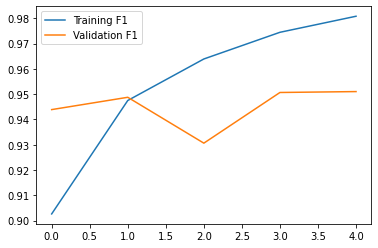

In [89]:
plt.plot(TRAIN_F1, label='Training F1')
plt.plot(VAL_F1, label='Validation F1')
plt.legend()
plt.show()


In [16]:
def make_data_loader_predict(ids, masks, BATCH_SIZE=4):
    data = TensorDataset(ids, masks)
    sampler = SequentialSampler(data)
    dataloader = DataLoader(data, sampler=sampler, batch_size=BATCH_SIZE)
    return dataloader


In [17]:
def predictSentiment(model, sense):
  predicts = []
  test_ids = convert_sents_ids(sense)
  test_masks = make_mask(test_ids)
  test_dataloader = make_data_loader_predict(test_ids, test_masks)
  for batch in tqdm(test_dataloader):
       batch = tuple(t.to('cuda') for t in batch)
       b_input_ids, b_input_mask = batch
  with torch.no_grad():
    outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    logits = outputs[0]
    logits = logits.detach().cpu().numpy()
    predicts.append(np.argmax(logits, axis=1))
    predicts = np.array(predicts).flatten()
  return predicts

In [26]:
!zip -r /kaggle/working/model.zip /kaggle/working/5

  adding: kaggle/working/5/ (stored 0%)
  adding: kaggle/working/5/config.json (deflated 51%)
  adding: kaggle/working/5/pytorch_model.bin (deflated 18%)


In [18]:
config1 = RobertaConfig.from_pretrained(
    "/kaggle/input/model-config/config.json", from_tf=False, num_labels = 2, output_hidden_states=False,
)
PHO_BERT1 = RobertaForSequenceClassification.from_pretrained(
    "/kaggle/input/model-pytorch/pytorch_model.bin",
    config=config1
)

PHO_BERT1.cuda()
print('Done')

Done


In [1]:
!pip install gradio --use-deprecated=legacy-resolver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 51.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 KB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.3/288.3 KB 26.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 KB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 KB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 KB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 KB 7.4 MB/s eta 0:00:00
  Created wheel for ffmpy: filename=ffmpy-0.3.0-py3-none-any.whl size=4712 sha256=d2762de577db3ff7656b855ad6f592eab54fd8608d017f47b29645864ed239cf
  Stored in directory: /root/.cache/pip/wheels/13/e4/6c/e8059816e86796a597c6e6b0d4c880630f51a1fcfa0befd5e6
Successfully built ffmpy
  Attempting uninstall: pygm

In [2]:
import gradio as gr

In [19]:
def make_prediction(comment):
    comment_array = []
    comment_array.append(comment)
    prediction = predictSentiment(PHO_BERT1, comment_array)
    if (prediction[0] == 1):
        return "Đây là phản hồi tích cực"
    else:
        return "Đây là phản hồi tiêu cực, cần được xem xét để cải thiện"

In [20]:
# Create the Gradio interface
comment_input = gr.Textbox(label="Nhập phản hồi của học sinh: ")
output = gr.Textbox()
interface = gr.Interface(fn=make_prediction, inputs=[comment_input], outputs=output)
# Launch the interface
interface.launch()

Kaggle notebooks require sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Running on local URL:  http://127.0.0.1:7861
Running on public URL: https://e851b54e18e4502dd6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]